# Two-Dimensional Advection on a Periodic Domain

Advection transports a scalar quantity by a velocity field. It describes the motion of dye, temperature, density, and image texture. In the absence of sources and diffusion, the scalar $f(t,x)$ solves
$$
\partial_t f+u\cdot\nabla f=0.
$$
Along a characteristic $X'(t)=u(X(t))$, the transported value is constant: $\frac{d}{dt}f(t,X(t))=0$. This relation turns the PDE into the backward image warp used below.

The numerical goal is not merely to move a texture. A useful scheme should respect periodic boundaries, remain stable during long trajectories, and reveal its own interpolation-induced diffusion. We use a semi-Lagrangian method, trace output pixels backward through a smooth incompressible flow, and monitor the gradual smoothing of sharp structures.


## Environment and symbols

The scalar field is stored as a matrix $f\in\mathbb{R}^{n\times n}$ and the velocity as $u\in\mathbb{R}^{n\times n\times 2}$.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
rng = np.random.default_rng(1234)

notebook_dir = Path('python/advection')
snippet_path = notebook_dir / 'snippet.png' if notebook_dir.is_dir() else Path('snippet.png')


## Periodic interpolation operators

If $\mathcal W_v$ denotes periodic bilinear interpolation displaced by $v$, the semi-Lagrangian update is
$$
f^{k+1}=\mathcal W_{\rho u}(f^k),\qquad (\mathcal W_vf)(x)\approx f(x-v(x)).
$$
The four bilinear weights are nonnegative and sum to one. This makes the update stable and bounded, while explaining why repeated interpolation gradually damps high-frequency contrast.


In [2]:
def gaussian_kernel_2d(n, sigma):
    t = np.r_[np.arange(0, n // 2 + 1), np.arange(-n // 2 + 1, 0)]
    g1 = np.exp(-(t**2) / (2 * sigma**2))
    G = np.outer(g1, g1)
    return G / G.sum()

def periodic_gaussian_filter(f, sigma):
    n = f.shape[0]
    G = gaussian_kernel_2d(n, sigma)
    return np.fft.ifft2(np.fft.fft2(f) * np.fft.fft2(G)).real

def warp_periodic_bilinear(f, U):
    n = f.shape[0]
    yy, xx = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
    x = (xx - U[..., 0]) % n
    y = (yy - U[..., 1]) % n
    x0 = np.floor(x).astype(int)
    y0 = np.floor(y).astype(int)
    x1 = (x0 + 1) % n
    y1 = (y0 + 1) % n
    wx = x - x0
    wy = y - y0
    f00 = f[y0, x0]
    f10 = f[y0, x1]
    f01 = f[y1, x0]
    f11 = f[y1, x1]
    return (
        (1 - wx) * (1 - wy) * f00
        + wx * (1 - wy) * f10
        + (1 - wx) * wy * f01
        + wx * wy * f11
    )

## Initial condition

We use a high-contrast grid texture to make transport distortions visually explicit.

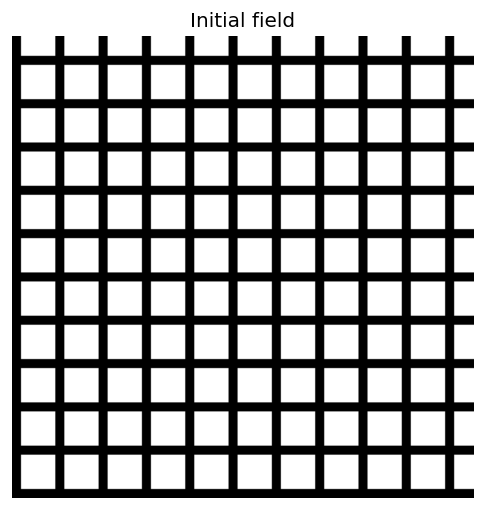

In [3]:
n = 256
Y, X = np.meshgrid(np.arange(n), np.arange(n), indexing='ij')
cell = 24
line = 4
f0 = 1.0 - ((X % cell <= line) | (Y % cell <= line)).astype(float)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(f0, cmap='gray', origin='lower')
ax.set_title('Initial field')
ax.axis('off')
plt.show()

## A smooth incompressible velocity field

To focus on transport rather than compression, we construct a periodic velocity from a stream function $\psi$:
$$
u=(\partial_y\psi,-\partial_x\psi),\qquad \nabla\cdot u=0.
$$
After smoothing $\psi$, we normalize the speed so that one step displaces a point by only a few pixels, while the full sequence travels substantially across the periodic square.


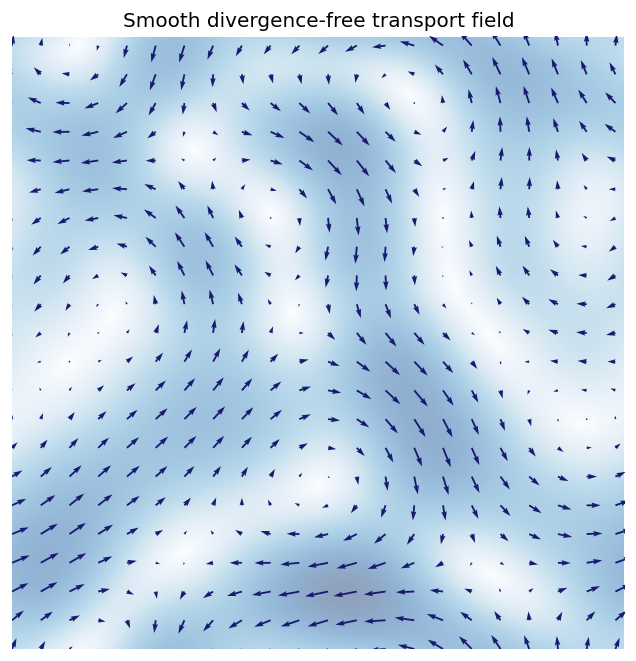

In [4]:
sigma_flow = 34
stream_function = periodic_gaussian_filter(rng.standard_normal((n, n)), sigma_flow)
u_x = 0.5 * (np.roll(stream_function, -1, axis=0) - np.roll(stream_function, 1, axis=0))
u_y = -0.5 * (np.roll(stream_function, -1, axis=1) - np.roll(stream_function, 1, axis=1))
U = np.stack([u_x, u_y], axis=-1)
U /= np.linalg.norm(U, axis=-1).max() + 1e-12

arrow_step = 12
fig, ax = plt.subplots(figsize=(5.4, 5.4), constrained_layout=True)
speed = np.linalg.norm(U, axis=-1)
ax.imshow(speed, origin='lower', cmap='Blues', alpha=0.45)
ax.quiver(X[::arrow_step, ::arrow_step], Y[::arrow_step, ::arrow_step],
          U[::arrow_step, ::arrow_step, 0], U[::arrow_step, ::arrow_step, 1],
          color='midnightblue', angles='xy', scale_units='xy', scale=0.10, width=0.003)
ax.set(xlim=(0, n), ylim=(0, n), aspect='equal', title='Smooth divergence-free transport field')
ax.axis('off')
plt.show()


## Semi-Lagrangian evolution

Each update traces from $x$ to $x-\rho u(x)$ and samples the previous field at that departure point. This backward construction is stable even when a characteristic crosses several cells. We use $\rho=2.5$ pixels per step and 100 steps, allowing a visible long-range periodic deformation.


In [5]:
def advect(field_initial, velocity, displacement_scale=2.5, n_steps=100):
    sequence = [field_initial.copy()]
    field = field_initial.copy()
    for _ in range(n_steps):
        field = warp_periodic_bilinear(field, displacement_scale * velocity)
        sequence.append(field.copy())
    return np.asarray(sequence)


rho = 2.5
n_steps = 100
frames = advect(f0, U, displacement_scale=rho, n_steps=n_steps)
means = frames.mean(axis=(1, 2))
contrasts = frames.std(axis=(1, 2))


## Transport geometry and numerical diffusion

For an incompressible continuous flow, the mean and variance of a transported scalar are conserved. The static frames show the geometric deformation; the final panel exposes the numerical trade-off. Bilinear interpolation keeps the evolution stable and the mean nearly constant, but repeated resampling decreases contrast and smooths the sharp grid.


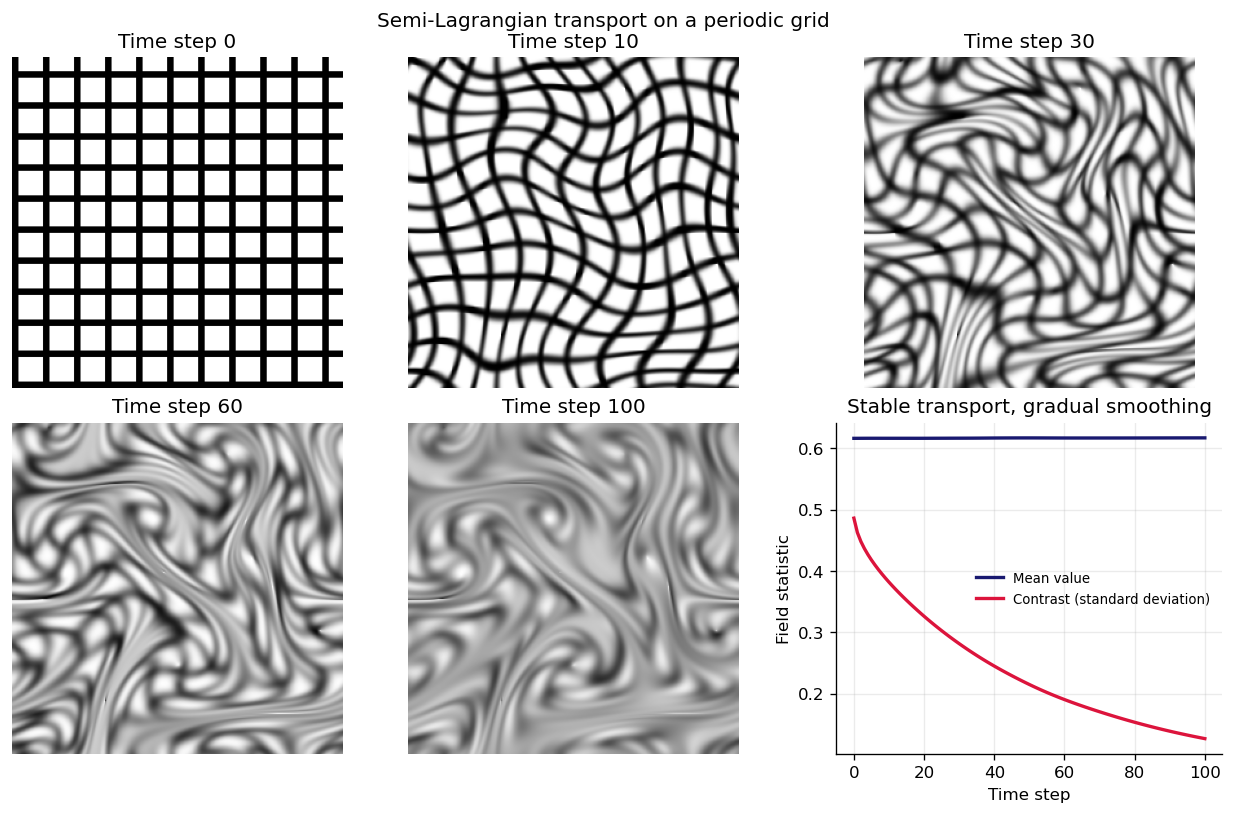

In [6]:
snapshot_steps = [0, 10, 30, 60, n_steps]
fig, axes = plt.subplots(2, 3, figsize=(10.4, 6.5), constrained_layout=True)
for ax, step_index in zip(axes.flat[:5], snapshot_steps):
    ax.imshow(frames[step_index], cmap='gray', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Time step {step_index}')
    ax.axis('off')

metric_ax = axes.flat[5]
metric_ax.plot(means, color='midnightblue', lw=2, label='Mean value')
metric_ax.plot(contrasts, color='crimson', lw=2, label='Contrast (standard deviation)')
metric_ax.set(xlabel='Time step', ylabel='Field statistic', title='Stable transport, gradual smoothing')
metric_ax.legend(frameon=False, fontsize=8)
metric_ax.grid(alpha=0.25)
fig.suptitle('Semi-Lagrangian transport on a periodic grid', y=1.02)

snippet_fig, snippet_ax = plt.subplots(figsize=(5, 5), constrained_layout=True)
snippet_ax.imshow(frames[60], cmap='gray', origin='lower', vmin=0, vmax=1)
snippet_ax.set_title('Periodic advection after 60 steps')
snippet_ax.axis('off')
snippet_fig.savefig(snippet_path, facecolor='white')
plt.close(snippet_fig)
plt.show()


## Interactive time evolution

Use the slider to select a stored time step, or press play to scan the sequence at a fixed cadence. The widget reads precomputed frames only; it is isolated from the solver and tagged interactive, so automated execution still stores all static figures without running interface code.


In [ ]:
def show_frame(step_index):
    fig, ax = plt.subplots(figsize=(5.2, 5.2), constrained_layout=True)
    ax.imshow(frames[step_index], cmap='gray', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Time step {step_index}: contrast {contrasts[step_index]:.3f}')
    ax.axis('off')
    plt.show()


time_slider = widgets.IntSlider(value=0, min=0, max=n_steps, step=1, description='Time step', continuous_update=False)
play = widgets.Play(value=0, min=0, max=n_steps, step=1, interval=110, description='Play')
widgets.jslink((play, 'value'), (time_slider, 'value'))
display(widgets.HBox([play, time_slider]), widgets.interactive_output(show_frame, {'step_index': time_slider}))


## Takeaways

Semi-Lagrangian advection converts characteristic tracing into a stable periodic image warp. It is robust over long trajectories, but its interpolation operator damps fine-scale contrast. The frame sequence and contrast curve make this stability-versus-sharpness trade-off explicit.


## Bibliographical resources

- Randall J. LeVeque, *Finite Volume Methods for Hyperbolic Problems*, 2002.
- Ronald Fedkiw, Jos Stam, and Henrik Wann Jensen, *Visual Simulation of Smoke*, 2001.
- Jos Stam, *Stable Fluids*, 1999.
- Jean-Daniel Benamou and Yann Brenier, *A Computational Fluid Mechanics Solution to the Monge–Kantorovich Mass Transfer Problem*, 2000.
